Task 3-2

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize

# Baseline CNN
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train and evaluate
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]}")
print(f"Test Accuracy: {test_acc}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7683 - loss: 0.6438 - val_accuracy: 0.8677 - val_loss: 0.3650
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 73s 34ms/step - accuracy: 0.8817 - loss: 0.3185 - val_accuracy: 0.8903 - val_loss: 0.3008
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9013 - loss: 0.2726 - val_accuracy: 0.8835 - val_loss: 0.3146
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9137 - loss: 0.2345 - val_accuracy: 0.9022 - val_loss: 0.2648
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9230 - loss: 0.2057 - val_accuracy: 0.9051 - val_loss: 0.2622
313/313 - 3s - 8ms/step - accuracy: 0.9018 - loss: 0.2759
Training Accuracy: 0.9242500066757202
Validation Accuracy: 0.9050833582878113
Test Accuracy: 0.9017999768257141


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


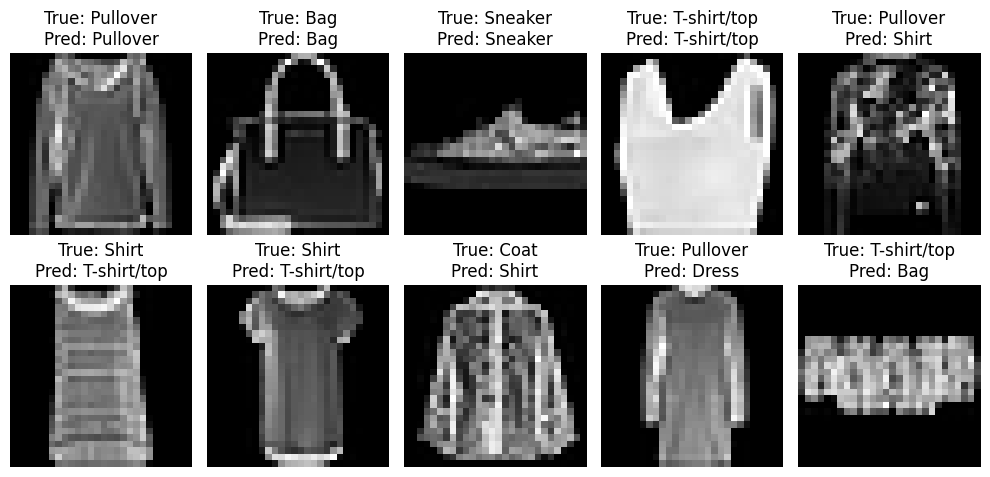

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Select 5 random samples from the test set
# sample_indices = np.random.choice(len(x_test), 5, replace=False)
# sample_indices

# sample_indices = [5792, 9453, 3633, 3236, 9531] # with one error sample
# sample_indices = [2485, 6008, 1104, 3457, 2599]

def genearate_sample_images(model):
  sample_indices = [5792, 9453, 3633, 3236, 9531, 2485, 6008, 1104, 3457, 2599] # with one error sample
  sample_images = x_test[sample_indices]
  sample_labels = y_test[sample_indices]

  # Predict using the trained model
  predictions = model.predict(sample_images)

  # Map class indices to Fashion MNIST labels
  class_names = [
      'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
      'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
  ]

  # Plot the samples with predictions
  plt.figure(figsize=(10, 5))
  for i in range(10):
      plt.subplot(2, 5, i + 1)
      plt.imshow(sample_images[i], cmap='gray')
      predicted_label = np.argmax(predictions[i])
      true_label = sample_labels[i]
      plt.title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}")
      plt.axis('off')
  plt.tight_layout()
  plt.show()

  # sample_false_indices = [5792, 9453, 3633, 3236, 9531] # with one error sample
  # # sample_indices = [2485, 6008, 1104, 3457, 2599]
  # sample_images = x_test[sample_false_indices]
  # sample_labels = y_test[sample_false_indices]

  # # Predict using the trained model
  # predictions = model.predict(sample_images)

  # # Map class indices to Fashion MNIST labels
  # class_names = [
  #     'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
  #     'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
  # ]

  # # Plot the incorrect predictions
  # plt.figure(figsize=(10, 5))
  # for i in range(5):
  #     plt.subplot(1, 5, i + 1)
  #     plt.imshow(sample_images[i], cmap='gray')
  #     true_label = class_names[sample_labels[i]]
  #     pred_label = class_names[np.argmax(predictions[i])]
  #     plt.title(f"True: {true_label}\nPred: {pred_label}", color='red')
  #     plt.axis('off')
  # plt.tight_layout()
  # plt.show()

genearate_sample_images(model)

# With dropout

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# # Baseline CNN
# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# # Baseline CNN + Dropout
# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.25),
#     layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# # Baseline CNN + Batch Normalization
# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.BatchNormalization(),
#     layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# # Deeper CNN
# model = models.Sequential([
#     layers.Reshape((28, 28, 1), input_shape=(28, 28)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(128, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(256, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])

# All combined
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train and evaluate
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)
# history = model.fit(x_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stopping])
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]}")
print(f"Test Accuracy: {test_acc}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 87s 55ms/step - accuracy: 0.7247 - loss: 0.7653 - val_accuracy: 0.8241 - val_loss: 0.4776
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.8376 - loss: 0.4405 - val_accuracy: 0.8512 - val_loss: 0.4035
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.8570 - loss: 0.3882 - val_accuracy: 0.8673 - val_loss: 0.3490
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - accuracy: 0.8730 - loss: 0.3506 - val_accuracy: 0.8742 - val_loss: 0.3376
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 88s 55ms/step - accuracy: 0.8765 - loss: 0.3363 - val_accuracy: 0.8855 - val_loss: 0.3117
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.8823 - loss: 0.3187 - val_accuracy: 0.8811 - val_loss: 0.3211
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 141s 55ms/step - accuracy: 0.8887 - loss: 0.3000 - val_accuracy: 0.8907 - val_loss: 0.2943
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 144s 57ms/step - accuracy: 0.8890

KeyboardInterrupt: 

In [ ]:
genearate_sample_images(model)